# Proyecto final

## Índice 
1. Introducción  
2. Carga de dataset 
3. Categories
4. Products
5. Orders
6. Reviews
7. Payments
8. Order items
9. Customer
10. Geolocation 
11. Sellers

---

---

1. Introducción 

Datos sacados de : https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce

In [137]:
import pandas as pd
import sidetable as stb

---

2. Carga de dataset

In [138]:
df_sellers = pd.read_csv("../data/raw/olist_sellers_dataset.csv")
df_products = pd.read_csv("../data/raw/olist_products_dataset.csv")
df_categories = pd.read_csv("../data/raw/olist_product_category_name_translation.csv")
df_orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")
df_reviews = pd.read_csv("../data/raw/olist_order_reviews_dataset.csv")
df_payments = pd.read_csv("../data/raw/olist_order_payments_dataset.csv")
df_order_items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")
df_customer = pd.read_csv("../data/raw/olist_customers_dataset.csv")

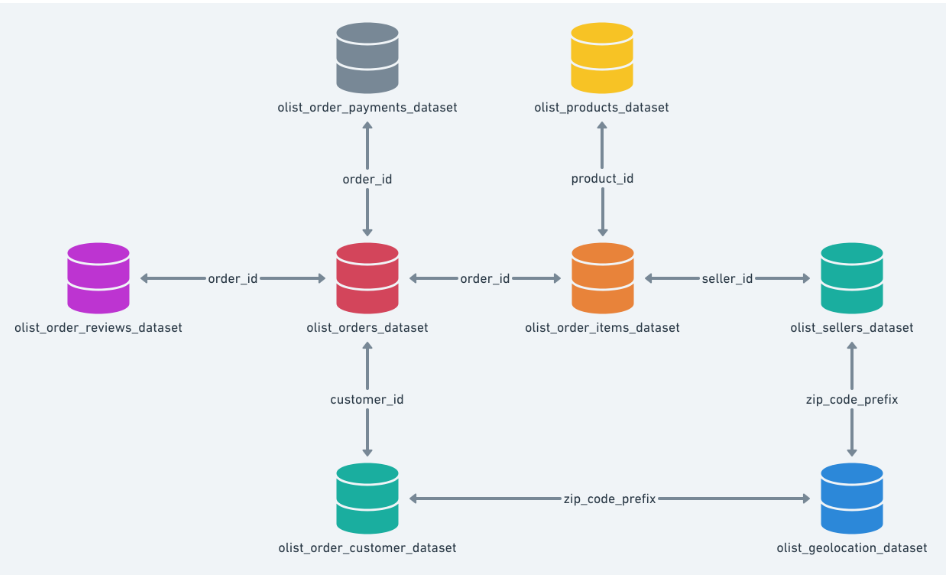

---

3. Categories

In [139]:
df_categories.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [140]:
df_categories.shape

(71, 2)

In [141]:
df_categories.info()

<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   product_category_name          71 non-null     str  
 1   product_category_name_english  71 non-null     str  
dtypes: str(2)
memory usage: 1.2 KB


In [142]:
df_categories.stb.missing()

,missing,total,percent
product_category_name,0,71,0.0
product_category_name_english,0,71,0.0


---

4. Products 

In [143]:
df_products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [144]:
df_products.shape

(32951, 9)

In [145]:
df_products.info()

<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 2.3 MB


In [146]:
df_products.stb.missing()

,missing,total,percent
product_category_name,610,32951,1.851234
product_description_lenght,610,32951,1.851234
product_name_lenght,610,32951,1.851234
product_photos_qty,610,32951,1.851234
product_weight_g,2,32951,0.006070
product_height_cm,2,32951,0.006070
product_length_cm,2,32951,0.006070
product_width_cm,2,32951,0.006070
product_id,0,32951,0.000000


In [147]:
df_products.duplicated().sum()

np.int64(0)

In [148]:
# Fusión de productos y categorías 

df_categories.columns =["category_pt", "category_en"]

df_products = df_products[["product_id", 'product_category_name', 'product_weight_g','product_length_cm', 'product_height_cm', 'product_width_cm']]
df_products.columns = ['id_product', 'category', 'weight_g', 'lengh_cm', 'heigh_cm', 'width_cm']

nuevas_filas = pd.DataFrame({
    "category_pt": ["pc_gamer", "portateis_cozinha_e_preparadores_de_alimentos"], 
    'category_en': ['pc_gamer', 'kitchenware_and_food_preparars']
})

df_categories = pd.concat([df_categories, nuevas_filas], ignore_index= True)

df_products = pd.merge(
    df_products, 
    df_categories[["category_pt", "category_en"]], 
    left_on="category", 
    right_on="category_pt", 
    how="outer"
)

df_products = df_products.drop(columns= ["category"])

df_products["category_en"] = df_products["category_en"].fillna("unknow")
df_products["category_pt"] = df_products["category_pt"].fillna("unknow")

df_products["weight_g"] = df_products["weight_g"].fillna(df_products["weight_g"].mean())
df_products["lengh_cm"] = df_products["lengh_cm"].fillna(df_products["lengh_cm"].mean())
df_products['heigh_cm'] = df_products['heigh_cm'].fillna(df_products['heigh_cm'].mean())
df_products['width_cm'] = df_products['width_cm'].fillna(df_products['width_cm'].mean())

df_products


,id_product,weight_g,lengh_cm,heigh_cm,width_cm,category_pt,category_en
0,07f01b6fcacc1b187a71e5074199db2d,16400.0,63.0,66.0,56.0,agro_industria_e_comercio,agro_industry_and_commerce
1,613d093272cb8f74f25a01e430155a6a,1050.0,38.0,41.0,39.0,agro_industria_e_comercio,agro_industry_and_commerce
2,980ecbcc15fe174ec1e5757c4d75b1bf,250.0,17.0,3.0,10.0,agro_industria_e_comercio,agro_industry_and_commerce
3,ba1d7e7ee1f055d252a2faa8ea3cea9b,1900.0,45.0,15.0,40.0,agro_industria_e_comercio,agro_industry_and_commerce
4,137ace556a03792cdc43f91ec621426d,550.0,16.0,19.0,11.0,agro_industria_e_comercio,agro_industry_and_commerce
...,...,...,...,...,...,...,...
32946,b0a0c5dd78e644373b199380612c350a,1800.0,30.0,20.0,70.0,unknow,unknow
32947,10dbe0fbaa2c505123c17fdc34a63c56,800.0,30.0,10.0,23.0,unknow,unknow
32948,bd2ada37b58ae94cc838b9c0569fecd8,200.0,21.0,8.0,16.0,unknow,unknow
32949,fa51e914046aab32764c41356b9d4ea4,1300.0,45.0,16.0,45.0,unknow,unknow


---

5. orders

In [149]:
df_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [150]:
df_orders.shape

(99441, 8)

In [151]:
df_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [152]:
# Conversión de columnas de str a fecha
fechas = ['order_purchase_timestamp','order_approved_at','order_delivered_carrier_date','order_delivered_customer_date','order_estimated_delivery_date']

for col in fechas: 
    df_orders[col] = pd.to_datetime(df_orders[col])

df_orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15


In [153]:
df_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 6.1 MB


In [154]:
df_orders.stb.missing()

,missing,total,percent
order_delivered_customer_date,2965,99441,2.981668
order_delivered_carrier_date,1783,99441,1.793023
order_approved_at,160,99441,0.160899
order_id,0,99441,0.000000
order_purchase_timestamp,0,99441,0.000000
order_status,0,99441,0.000000
customer_id,0,99441,0.000000
order_estimated_delivery_date,0,99441,0.000000


Aunque hay nulos, no se deben eliminar porque en este caso, lo nulos existen porque no todos los pedidos se entregaron 
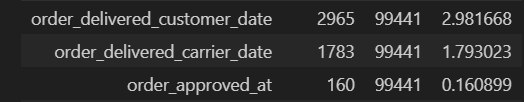

Estas columnas nos indican pedidos cancelados, pedidos no enviados y pedidos en proceso

In [155]:
df_orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [156]:
# Comprobación de nulo de pedidos entregados
df_orders[df_orders["order_status"]== "delivered"].isna().sum()

# ~100000 pedidos
# solo 8 pedidos entregados no tiene fecha de entrega registrada

order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      2
order_delivered_customer_date     8
order_estimated_delivery_date     0
dtype: int64

In [157]:
# Eliminación de los 8 registros 

df_orders = df_orders.dropna(subset=["order_delivered_customer_date"])

In [158]:
df_orders.duplicated().sum()

np.int64(0)

In [159]:
# Creación de variables 

# Tiempo de entrega real
df_orders["delivery_time_days"] = (
     df_orders["order_delivered_customer_date"] - df_orders["order_purchase_timestamp"]
).dt.days

# Retraso de entrega 
df_orders["delivery_delay"] = (
     df_orders["order_delivered_customer_date"] - df_orders["order_estimated_delivery_date"]
).dt.days

---

6. Reviews

In [160]:
df_reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [161]:
df_reviews.shape

(99224, 7)

In [162]:
df_reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   review_id                99224 non-null  str  
 1   order_id                 99224 non-null  str  
 2   review_score             99224 non-null  int64
 3   review_comment_title     11568 non-null  str  
 4   review_comment_message   40977 non-null  str  
 5   review_creation_date     99224 non-null  str  
 6   review_answer_timestamp  99224 non-null  str  
dtypes: int64(1), str(6)
memory usage: 5.3 MB


In [163]:
df_reviews.stb.missing()

,missing,total,percent
review_comment_title,87656,99224,88.341530
review_comment_message,58247,99224,58.702532
review_id,0,99224,0.000000
review_score,0,99224,0.000000
order_id,0,99224,0.000000
review_creation_date,0,99224,0.000000
review_answer_timestamp,0,99224,0.000000


In [164]:
# Conversión de nulos y fechas 
df_reviews["review_comment_title"] = df_reviews["review_comment_title"].fillna("No comment")
df_reviews['review_comment_message'] = df_reviews['review_comment_message'].fillna('No comment')

df_reviews["review_creation_date"] = pd.to_datetime(df_reviews["review_creation_date"])
df_reviews["review_answer_timestamp"] = pd.to_datetime(df_reviews["review_answer_timestamp"])

df_reviews

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,No comment,No comment,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,No comment,No comment,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,No comment,No comment,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,No comment,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,No comment,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,No comment,No comment,2018-07-07,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,No comment,No comment,2017-12-09,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,No comment,"Excelente mochila, entrega super rápida. Super...",2018-03-22,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,No comment,No comment,2018-07-01,2018-07-02 12:59:13


---

7. Payments

In [165]:
df_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [166]:
df_payments.shape

(103886, 5)

In [167]:
df_payments.info()

<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  str    
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  str    
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 4.0 MB


In [168]:
df_payments.stb.missing()

,missing,total,percent
order_id,0,103886,0.0
payment_sequential,0,103886,0.0
payment_type,0,103886,0.0
payment_installments,0,103886,0.0
payment_value,0,103886,0.0


In [169]:
df_payments["payment_type"] = df_payments["payment_type"].replace(
    {"boleto": "ticket"}
)

df_payments

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
...,...,...,...,...,...
103881,0406037ad97740d563a178ecc7a2075c,1,ticket,1,363.31
103882,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80
103883,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77
103884,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54


---

8. Order items

In [170]:
df_order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [171]:
df_order_items.shape

(112650, 7)

In [172]:
df_order_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 6.0 MB


In [173]:
df_order_items.stb.missing()

,missing,total,percent
order_id,0,112650,0.0
order_item_id,0,112650,0.0
product_id,0,112650,0.0
seller_id,0,112650,0.0
shipping_limit_date,0,112650,0.0
price,0,112650,0.0
freight_value,0,112650,0.0


In [174]:
# Conversión a fecha 

df_order_items["shipping_limit_date"] = pd.to_datetime(df_order_items["shipping_limit_date"])
df_order_items

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72


In [175]:
df_order_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  str           
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  str           
 3   seller_id            112650 non-null  str           
 4   shipping_limit_date  112650 non-null  datetime64[us]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(1), str(3)
memory usage: 6.0 MB


---

9. Customer

In [176]:
df_customer.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [177]:
df_customer.columns = ["id_customer_order", "id_user", "zip_code_prefix", "city", "state"]
# id_customer se genera al realizar una order, mientras que id_unique identifica al usuario

In [178]:
df_customer.shape

(99441, 5)

In [179]:
df_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   id_customer_order  99441 non-null  str  
 1   id_user            99441 non-null  str  
 2   zip_code_prefix    99441 non-null  int64
 3   city               99441 non-null  str  
 4   state              99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


In [180]:
df_customer.stb.missing()

,missing,total,percent
id_customer_order,0,99441,0.0
id_user,0,99441,0.0
zip_code_prefix,0,99441,0.0
city,0,99441,0.0
state,0,99441,0.0


In [181]:
df_customer.duplicated().sum()

np.int64(0)

---

10. Geolocation 

In [182]:
df_sellers.columns=["id_seller", "zip_code_prefix", "city", "state"]
columns = ["zip_code_prefix", "city", "state"]
seller_location = df_sellers[columns]
customer_location = df_customer[columns]

df_geolocation = pd.concat([customer_location, seller_location ])

df_customer = df_customer.drop(columns=["city", "state"])
df_sellers = df_sellers.drop(columns=["city", "state"])

df_geolocation = df_geolocation.drop_duplicates(subset="zip_code_prefix")

df_geolocation["city"] = df_geolocation["city"].str.split(r' -|/').str[0]
df_geolocation["city"] = df_geolocation["city"].str.strip()

df_geolocation["city"] = df_geolocation["city"].str.title()

In [183]:
df_geolocation.stb.missing()

,missing,total,percent
zip_code_prefix,0,15078,0.0
city,0,15078,0.0
state,0,15078,0.0


In [184]:
df_geolocation.head()

,zip_code_prefix,city,state
0,14409,Franca,SP
1,9790,Sao Bernardo Do Campo,SP
2,1151,Sao Paulo,SP
3,8775,Mogi Das Cruzes,SP
4,13056,Campinas,SP


---

11. Sellers

In [185]:
df_sellers.head()

,id_seller,zip_code_prefix
0,3442f8959a84dea7ee197c632cb2df15,13023
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195
4,51a04a8a6bdcb23deccc82b0b80742cf,12914


In [186]:
df_sellers.stb.missing()

,missing,total,percent
id_seller,0,3095,0.0
zip_code_prefix,0,3095,0.0


--- 

12. Dataset final

In [187]:
df_customer.head()

,id_customer_order,id_user,zip_code_prefix
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056


In [188]:
df_geolocation.head()

,zip_code_prefix,city,state
0,14409,Franca,SP
1,9790,Sao Bernardo Do Campo,SP
2,1151,Sao Paulo,SP
3,8775,Mogi Das Cruzes,SP
4,13056,Campinas,SP


In [189]:
df_sellers.head()

,id_seller,zip_code_prefix
0,3442f8959a84dea7ee197c632cb2df15,13023
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195
4,51a04a8a6bdcb23deccc82b0b80742cf,12914


In [190]:
df = df_orders.merge(
    df_customer,
    left_on="customer_id",
    right_on="id_customer_order",
    how="left"
)
df = df.merge(df_order_items, on="order_id")
df = df.merge(df_products, 
              left_on= "product_id",
              right_on="id_product", 
              how="left")
df = df.merge(df_sellers, 
              left_on= "seller_id",
              right_on="id_seller",
              how="left")
df = df.merge(df_payments, on= "order_id")
df = df.merge(df_reviews, on= "order_id")


In [191]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time_days,delivery_delay,...,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8,-8,...,1,credit_card,1,18.12,a54f0611adc9ed256b57ede6b6eb5114,4,No comment,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8,-8,...,3,voucher,1,2.00,a54f0611adc9ed256b57ede6b6eb5114,4,No comment,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8,-8,...,2,voucher,1,18.59,a54f0611adc9ed256b57ede6b6eb5114,4,No comment,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13,-6,...,1,ticket,1,141.46,8d5266042046a06655c8db133d120ba5,4,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9,-18,...,1,credit_card,3,179.12,e73b67b67587f7644d5bd1a52deb1b01,5,No comment,No comment,2018-08-18,2018-08-22 19:07:58


In [192]:
df = df.renamedf = df.rename(columns={
    "zip_code_prefix_x": "customer_zip_code_prefix",
    "zip_code_prefix_y": "seller_zip_code_prefix"
})

C:\Users\patri\AppData\Local\Temp\ipykernel_18664\350944476.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df = df.renamedf = df.rename(columns={


In [193]:
df = df.merge(
    df_geolocation,
    left_on="customer_zip_code_prefix",
    right_on="zip_code_prefix",
    how="left"
)

In [194]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time_days,delivery_delay,...,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,zip_code_prefix,city,state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8,-8,...,18.12,a54f0611adc9ed256b57ede6b6eb5114,4,No comment,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,3149,Sao Paulo,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8,-8,...,2.00,a54f0611adc9ed256b57ede6b6eb5114,4,No comment,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,3149,Sao Paulo,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8,-8,...,18.59,a54f0611adc9ed256b57ede6b6eb5114,4,No comment,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,3149,Sao Paulo,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13,-6,...,141.46,8d5266042046a06655c8db133d120ba5,4,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50,47813,Barreiras,BA
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9,-18,...,179.12,e73b67b67587f7644d5bd1a52deb1b01,5,No comment,No comment,2018-08-18,2018-08-22 19:07:58,75265,Vianopolis,GO


In [195]:
df.shape

(114858, 41)

In [196]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114858 entries, 0 to 114857
Data columns (total 41 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       114858 non-null  str           
 1   customer_id                    114858 non-null  str           
 2   order_status                   114858 non-null  str           
 3   order_purchase_timestamp       114858 non-null  datetime64[us]
 4   order_approved_at              114843 non-null  datetime64[us]
 5   order_delivered_carrier_date   114857 non-null  datetime64[us]
 6   order_delivered_customer_date  114858 non-null  datetime64[us]
 7   order_estimated_delivery_date  114858 non-null  datetime64[us]
 8   delivery_time_days             114858 non-null  int64         
 9   delivery_delay                 114858 non-null  int64         
 10  id_customer_order              114858 non-null  str           
 11  id_user    

In [197]:
df.duplicated().sum()

np.int64(0)

In [198]:
df.isna().sum()

order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                15
order_delivered_carrier_date      1
order_delivered_customer_date     0
order_estimated_delivery_date     0
delivery_time_days                0
delivery_delay                    0
id_customer_order                 0
id_user                           0
customer_zip_code_prefix          0
order_item_id                     0
product_id                        0
seller_id                         0
shipping_limit_date               0
price                             0
freight_value                     0
id_product                        0
weight_g                          0
lengh_cm                          0
heigh_cm                          0
width_cm                          0
category_pt                       0
category_en                       0
id_seller                         0
seller_zip_code_prefix      

In [199]:
df.stb.missing()

,missing,total,percent
order_approved_at,15,114858,0.013060
order_delivered_carrier_date,1,114858,0.000871
order_id,0,114858,0.000000
order_status,0,114858,0.000000
customer_id,0,114858,0.000000
order_purchase_timestamp,0,114858,0.000000
order_delivered_customer_date,0,114858,0.000000
order_estimated_delivery_date,0,114858,0.000000
delivery_time_days,0,114858,0.000000
delivery_delay,0,114858,0.000000


In [200]:
# eliminar duplicado de geolocalización
df = df.drop(columns="zip_code_prefix")

# mantener solo los dos relevantes
df = df.rename(columns={
    "customer_zip_code_prefix": "customer_zip",
    "seller_zip_code_prefix": "seller_zip"
})

In [201]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time_days,delivery_delay,...,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,city,state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8,-8,...,1,18.12,a54f0611adc9ed256b57ede6b6eb5114,4,No comment,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,Sao Paulo,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8,-8,...,1,2.00,a54f0611adc9ed256b57ede6b6eb5114,4,No comment,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,Sao Paulo,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8,-8,...,1,18.59,a54f0611adc9ed256b57ede6b6eb5114,4,No comment,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,Sao Paulo,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13,-6,...,1,141.46,8d5266042046a06655c8db133d120ba5,4,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50,Barreiras,BA
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9,-18,...,3,179.12,e73b67b67587f7644d5bd1a52deb1b01,5,No comment,No comment,2018-08-18,2018-08-22 19:07:58,Vianopolis,GO


In [202]:
df.to_csv("../data/processed/olist_final_dataset.csv", index=False )